## Plotting the transmission matrix of ULTRASAT

In [2]:
import sncosmo
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In [3]:
# Load data files
transmission_matrix = np.loadtxt("./ULTRASAT_TR.dat", delimiter=",")
wavelengths = np.loadtxt("./wavelength.dat")
rdeg_values = np.loadtxt("./Rdeg.dat")

transmission_matrix = transmission_matrix[:]
wavelengths = wavelengths[:]

In [13]:
rdeg_values[10]



np.float64(4.22)

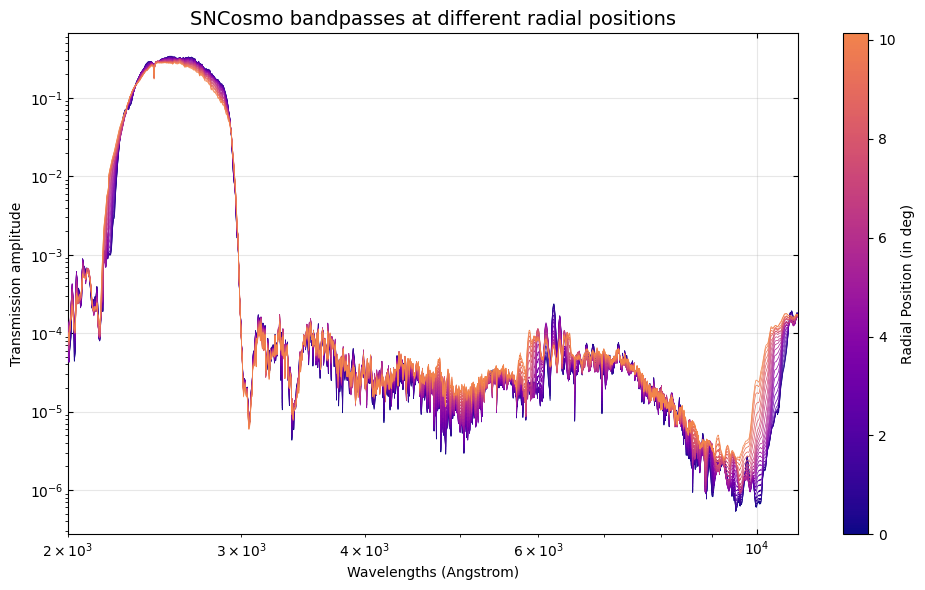

In [7]:
# Register each band in sncosmo
save_bandnames = []
plt.figure(figsize=(10, 6))

# Normalize frequencies for colormap
norm = plt.Normalize(vmin=np.min(rdeg_values), vmax=np.max(rdeg_values))
# cmap = cm.cividis  # or 'viridis', 'inferno', etc.
cmap = plt.get_cmap("plasma", 256)
newcolors = cmap(np.linspace(0, 0.7, 256))  # cut off the brightest end
cmap = cm.colors.ListedColormap(newcolors)

for i, rdeg in enumerate(rdeg_values):
    band_name = f"ultrasat_band_{rdeg:.2f}"  # Unique name for each radial position
    save_bandnames.append(band_name)
    transmission = transmission_matrix[:, i]

    # Create and register the band
    plt.plot(wavelengths, transmission, color=cmap(norm(rdeg)), linewidth=0.5, zorder=999)
    band = sncosmo.Bandpass(wavelengths, transmission, name=band_name)
    sncosmo.registry.register(band, force=True)

plt.xlabel('Wavelengths (Angstrom)')
plt.ylabel('Transmission amplitude')
plt.grid(True, alpha=0.3)
plt.xlim(min(wavelengths), max(wavelengths))

# Aesthetics
plt.tick_params(direction="in", top=True, right=True)
plt.xscale("log")
plt.yscale("log")
plt.title("SNCosmo bandpasses at different radial positions", fontsize=14)

# Create the colorbar
ax = plt.gca()
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label="Radial Position (in deg)")
plt.tight_layout()
plt.savefig("./ultrasat_transmission_matrix.png", dpi=300)
plt.show()